<a href="https://colab.research.google.com/github/tejaswinisoni13/animal_sound_project/blob/main/Animal_Sound_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tejaswinisonisgsits","key":"97b6d00f9b3ecec742d31697776d5f41"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ouaraskhelilrafik/tp-02-audio

Dataset URL: https://www.kaggle.com/datasets/ouaraskhelilrafik/tp-02-audio
License(s): other
100% 58.0M/58.0M [00:00<00:00, 82.1MB/s]



In [ ]:
!unzip -q tp-02-audio.zip -d audio_data

In [ ]:
import os

for root, dirs, files in os.walk("audio_data"):
    print("Folder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:5])
    print("-"*50)

Folder: audio_data
Subfolders: ['Data (ESC-10)', 'Data']
Files: []
--------------------------------------------------
Folder: audio_data/Data (ESC-10)
Subfolders: ['Data (ESC-10)']
Files: []
--------------------------------------------------
Folder: audio_data/Data (ESC-10)/Data (ESC-10)
Subfolders: ['002 - Rain', '004 - Baby cry', '006 - Person sneeze', '005 - Clock tick', '007 - Helicopter', '009 - Rooster', '001 - Dog bark', '003 - Sea waves', '010 - Fire crackling', '008 - Chainsaw']
Files: []
--------------------------------------------------
Folder: audio_data/Data (ESC-10)/Data (ESC-10)/002 - Rain
Subfolders: []
Files: ['5-198321-A.ogg', '3-143929-A.ogg', '1-26222-A.ogg', '5-203739-A.ogg', '5-193339-A.ogg']
--------------------------------------------------
Folder: audio_data/Data (ESC-10)/Data (ESC-10)/004 - Baby cry
Subfolders: []
Files: ['1-22694-A.ogg', '3-151081-A.ogg', '1-211527-A.ogg', '3-152007-B.ogg', '3-152007-C.ogg']
--------------------------------------------------


In [ ]:
!pip install -q librosa soundfile

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [ ]:
DATASET_PATH = "audio_data/Data/Data"
classes = os.listdir(DATASET_PATH)
print("Classes:", classes)

Classes: ['105 - Frog', '104 - Cow', '102 - Rooster', '103 - Pig', '101 - Dog']


In [ ]:
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.endswith(".ogg")]
    print(cls, ":", len(files))

105 - Frog : 40
104 - Cow : 40
102 - Rooster : 40
103 - Pig : 40
101 - Dog : 40


In [ ]:
IMG_SIZE = (128, 128)
MAX_AUDIO_LENGTH = 5  # seconds
SR = 22050

def extract_mel_spectrogram(file_path, sr=SR, max_length=MAX_AUDIO_LENGTH, img_size=IMG_SIZE):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr)

        target_length = sr * max_length

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        mel_spec_db = librosa.util.fix_length(mel_spec_db, size=img_size[1], axis=1)
        mel_spec_db = mel_spec_db[:img_size[0], :]

        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-6)

        return mel_spec_db
    except Exception as e:
        print(f"Error in {file_path}: {e}")
        return None

In [ ]:
X = []
y = []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    label_name = cls.split(" - ")[1]   # Dog, Cow, etc.

    for file in os.listdir(cls_path):
        if file.endswith(".ogg"):
            file_path = os.path.join(cls_path, file)
            features = extract_mel_spectrogram(file_path)

            if features is not None:
                X.append(features)
                y.append(label_name)

print("Total samples loaded:", len(X))
print("Total labels loaded:", len(y))

Total samples loaded: 200
Total labels loaded: 200


In [ ]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 128, 128)
y shape: (200,)


In [ ]:
X = X[..., np.newaxis]
print("New X shape:", X.shape)

New X shape: (200, 128, 128, 1)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)
print("y_cat shape:", y_cat.shape)

Classes: ['Cow' 'Dog' 'Frog' 'Pig' 'Rooster']
y_cat shape: (200, 5)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160, 128, 128, 1)
X_test : (40, 128, 128, 1)
y_train: (160, 5)
y_test : (40, 5)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
model = Sequential([
    Input(shape=(128, 128, 1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,629 (17.50 MB)

 Trainable params: 4,585,157 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_audio_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4339 - loss: 1.9733
Epoch 1: val_accuracy improved from None to 0.20000, saving model to best_audio_model.keras

Epoch 1: finished saving model to best_audio_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5375 - loss: 1.5611 - val_accuracy: 0.2000 - val_loss: 3.0181 - learning_rate: 0.0010
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7638 - loss: 0.6332
Epoch 2: val_accuracy did not improve from 0.20000
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7625 - loss: 0.6692 - val_accuracy: 0.2000 - val_loss: 3.8847 - learning_rate: 0.0010
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7566 - loss: 0.5606
Epoch 3: val_accuracy did not improve from 0.20000
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7625 - loss: 0.5673 - val_accuracy: 0.2000 - val_loss: 4.9528 - learning_rate: 0.0010
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8067 - loss: 0.4145

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Test Accuracy: 20.0 %


In [ ]:
import tensorflow as tf
import numpy as np

X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

X_train_rgb = tf.image.resize(X_train_rgb, (224, 224)).numpy()
X_test_rgb  = tf.image.resize(X_test_rgb, (224, 224)).numpy()

print("X_train_rgb shape:", X_train_rgb.shape)
print("X_test_rgb shape:", X_test_rgb.shape)

X_train_rgb shape: (160, 224, 224, 3)
X_test_rgb shape: (40, 224, 224, 3)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
X_train_ready = preprocess_input(X_train_rgb * 255.0)
X_test_ready  = preprocess_input(X_test_rgb * 255.0)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(5, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_mobilenet_audio.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train_ready, y_train,
    validation_data=(X_test_ready, y_test),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.2383 - loss: 2.3774
Epoch 1: val_accuracy improved from None to 0.77500, saving model to best_mobilenet_audio.keras

Epoch 1: finished saving model to best_mobilenet_audio.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 960ms/step - accuracy: 0.3187 - loss: 1.8956 - val_accuracy: 0.7750 - val_loss: 0.8452 - learning_rate: 0.0010
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.5912 - loss: 0.9410
Epoch 2: val_accuracy improved from 0.77500 to 0.87500, saving model to best_mobilenet_audio.keras

Epoch 2: finished saving model to best_mobilenet_audio.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 855ms/step - accuracy: 0.6562 - loss: 0.8936 - val_accuracy: 0.8750 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.7775 - loss: 0.6384
Epoch 3: val_accuracy improved from 0.87500 to 0.92500, saving model to best_mobilenet_audio.keras

Epoch 3: finished saving model to best_

In [ ]:
test_loss, test_acc = model.evaluate(X_test_ready, y_test, verbose=0)
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Test Accuracy: 100.0 %


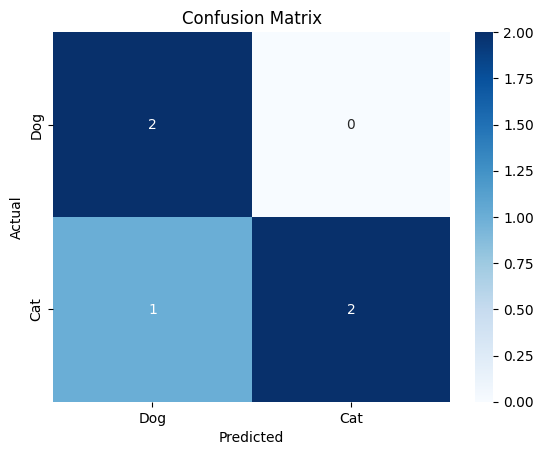

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Example labels
y_true = ['dog', 'cat', 'dog', 'dog', 'cat']
y_pred = ['dog', 'cat', 'cat', 'dog', 'cat']

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dog', 'Cat'],
            yticklabels=['Dog', 'Cat'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

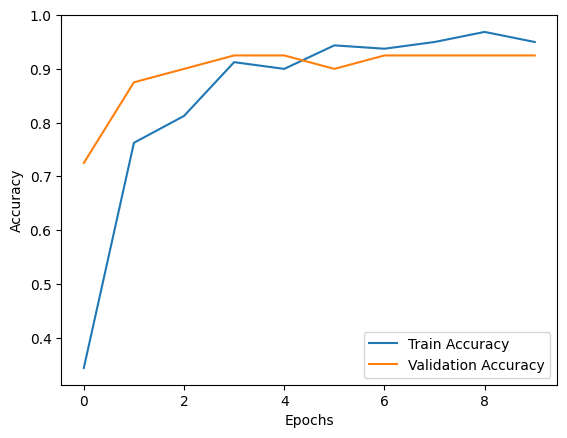

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

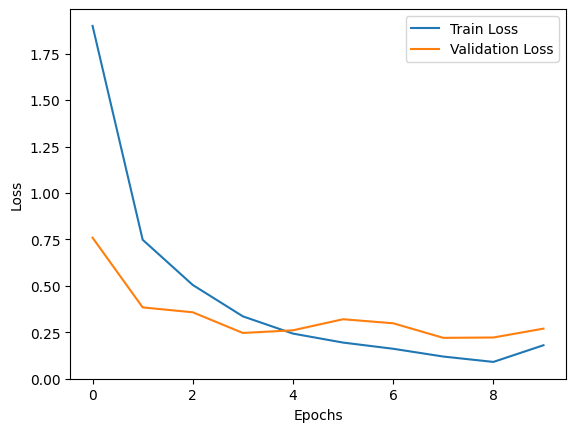

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.save("final_model.keras")

In [ ]:
import json

class_names = list(label_encoder.classes_)

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(class_names)

[np.str_('Cow'), np.str_('Dog'), np.str_('Frog'), np.str_('Pig'), np.str_('Rooster')]


In [ ]:
from google.colab import files

files.download("final_model.keras")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install flask tensorflow librosa numpy soundfile

In [ ]:
!ls

audio_data		    class_names.json   kaggle.json  tp-02-audio.zip
best_mobilenet_audio.keras  final_model.keras  sample_data


In [ ]:
# Step 1: Import libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 2: Your actual labels and predicted labels
# Replace with your model output
y_true = y_test        # actual labels
y_pred = model.predict(X_test)   # predicted labels

# If using probabilities (like Logistic Regression / NN), convert:
# y_pred = model.predict(X_test)
# OR (for probabilities)
# import numpy as np
# y_pred = np.argmax(model.predict(X_test), axis=1)

# Step 3: Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 4: Display it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_test' is not defined